# 02 - Exploratory Data Analysis (EDA)

**Tujuan:** Memahami karakteristik data `EURUSD_M15_cleaned.csv` secara mendalam sebelum training model.

**Fokus analisis:**
1. Distribusi signal & imbalanced data
2. Distribusi harga & indikator
3. Korelasi antar fitur
4. Pola signal berdasarkan waktu (jam, hari, bulan)
5. Validasi SL & TP (apakah wajar)
6. Kualitas label — apakah BUY/SELL punya pola yang bisa dipelajari model

## 1. Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('EURUSD_M15_cleaned.csv', index_col='datetime', parse_dates=True)

print(f'Shape: {df.shape}')
print(f'Range: {df.index.min()} → {df.index.max()}')
print(f'Kolom: {df.columns.tolist()}')
df.head(3)

Shape: (100248, 28)
Range: 2021-12-16 10:30:00 → 2026-03-25 18:30:00
Kolom: ['open', 'high', 'low', 'close', 'tick_vol', 'spread', 'ema_9', 'ema_21', 'ema_50', 'ema_200', 'rsi_14', 'macd_line', 'macd_signal', 'macd_hist', 'bb_upper', 'bb_mid', 'bb_lower', 'atr_14', 'body', 'upper_shadow', 'lower_shadow', 'candle_dir', 'return', 'return_3', 'return_5', 'signal', 'sl', 'tp']


,open,high,low,close,tick_vol,spread,ema_9,ema_21,ema_50,ema_200,...,body,upper_shadow,lower_shadow,candle_dir,return,return_3,return_5,signal,sl,tp
datetime,,,,,,,,,,,,,,,,,,,,,
2021-12-16 10:30:00,1.13026,1.13107,1.13021,1.13075,607,2,1.130074,1.129499,1.129038,1.128694,...,0.00049,0.00032,0.00005,1,0.000398,0.000212,0.000531,HOLD,NaN,NaN
2021-12-16 10:45:00,1.13082,1.13187,1.13082,1.13176,509,2,1.130411,1.129705,1.129145,1.128725,...,0.00094,0.00011,0.00000,1,0.000893,0.001194,0.001150,HOLD,NaN,NaN
2021-12-16 11:00:00,1.13177,1.13190,1.13128,1.13153,550,2,1.130635,1.129871,1.129239,1.128753,...,0.00024,0.00013,0.00025,-1,-0.000203,0.001088,0.000902,HOLD,NaN,NaN


## 2. Distribusi Signal — Imbalanced Check

=== Distribusi Signal ===
  HOLD:  84,447  (84.24%)
  BUY :   7,967  (7.95%)
  SELL:   7,834  (7.81%)


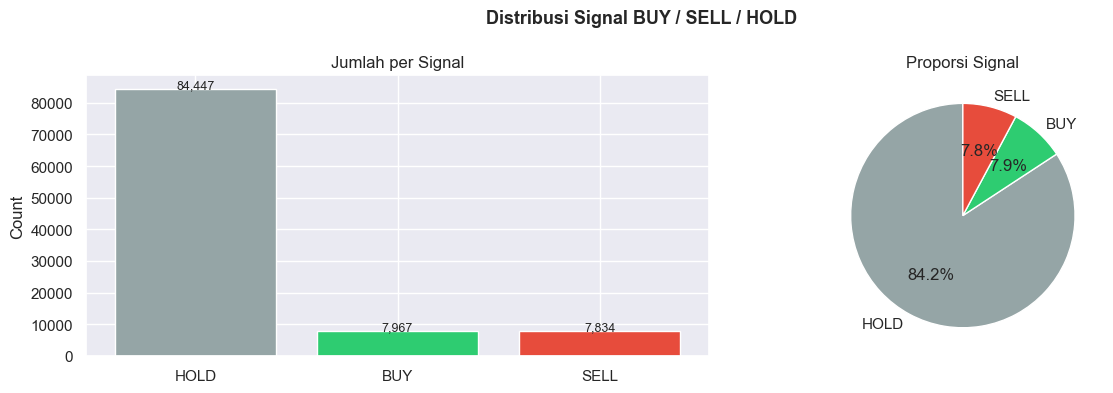


Rasio HOLD vs (BUY+SELL): 5.34x
⚠️  Data imbalanced — perlu ditangani saat training!


In [2]:
counts = df['signal'].value_counts()
pct    = df['signal'].value_counts(normalize=True).mul(100).round(2)

print('=== Distribusi Signal ===')
for s in counts.index:
    print(f'  {s:4s}: {counts[s]:>7,}  ({pct[s]}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

color_map = {'BUY': '#2ecc71', 'SELL': '#e74c3c', 'HOLD': '#95a5a6'}
bar_colors = [color_map[k] for k in counts.index]

axes[0].bar(counts.index, counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Jumlah per Signal')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=bar_colors, startangle=90)
axes[1].set_title('Proporsi Signal')

plt.suptitle('Distribusi Signal BUY / SELL / HOLD', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

ratio = counts['HOLD'] / (counts.get('BUY', 1) + counts.get('SELL', 1))
print(f'\nRasio HOLD vs (BUY+SELL): {ratio:.2f}x')
print('⚠️  Data imbalanced — perlu ditangani saat training!' if ratio > 3 else '✅ Distribusi cukup seimbang.')

## 3. Statistik Deskriptif per Signal

=== Mean per Signal ===
           rsi_14  macd_hist    atr_14      body  candle_dir    return
signal                                                                
BUY     50.415838   0.000003  0.000680  0.000385    0.011171  0.000002
HOLD    50.120253   0.000000  0.000769  0.000368    0.025093 -0.000000
SELL    50.012906  -0.000007  0.000668  0.000377    0.044677  0.000006


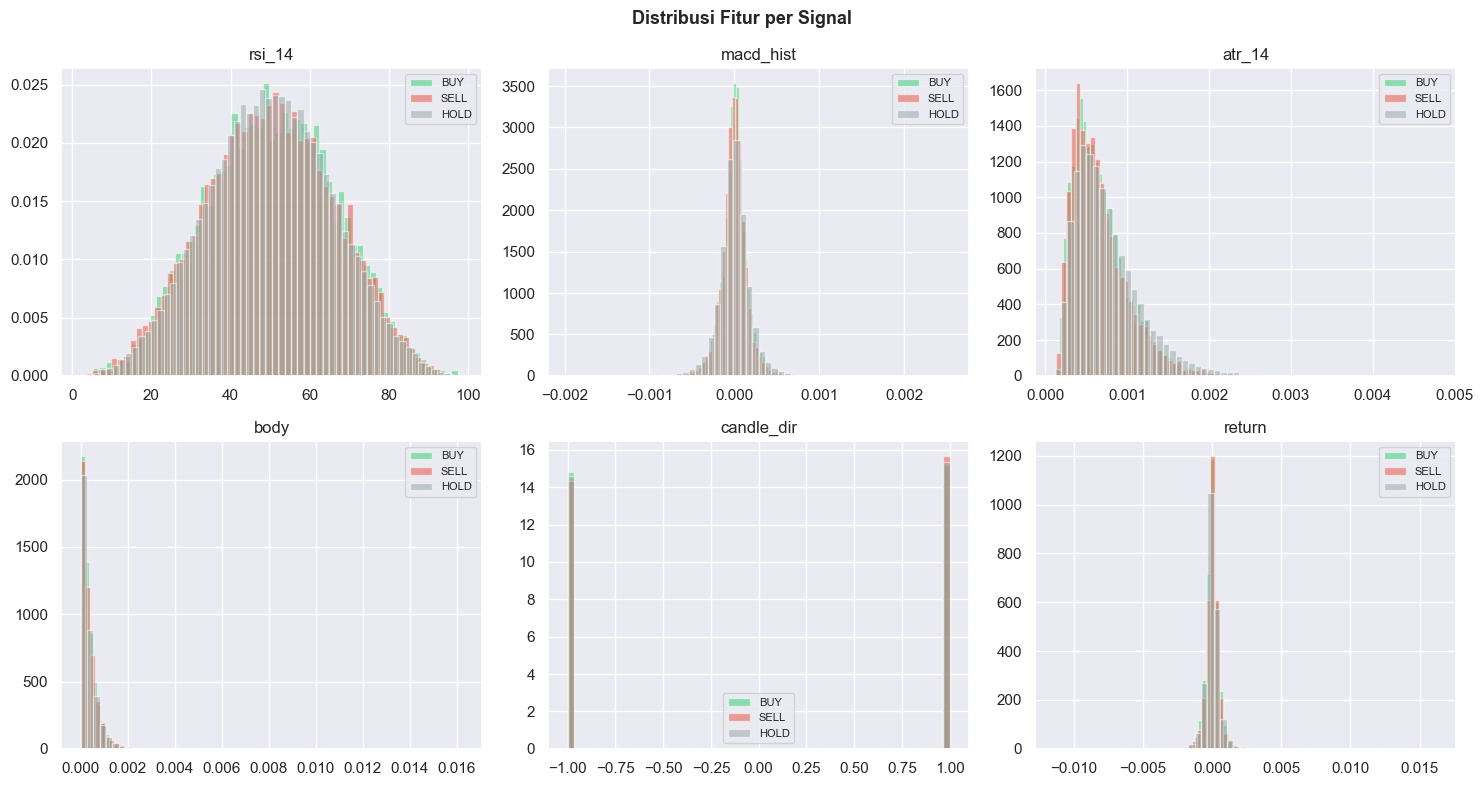

In [3]:
fitur_analisis = ['rsi_14', 'macd_hist', 'atr_14', 'body', 'candle_dir', 'return']

print('=== Mean per Signal ===')
print(df.groupby('signal')[fitur_analisis].mean().round(6).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(fitur_analisis):
    for sig, color in color_map.items():
        subset = df[df['signal'] == sig][col].dropna()
        axes[idx].hist(subset, bins=60, alpha=0.5, color=color, label=sig, density=True)
    axes[idx].set_title(col)
    axes[idx].legend(fontsize=8)

plt.suptitle('Distribusi Fitur per Signal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Pola Signal Berdasarkan Waktu

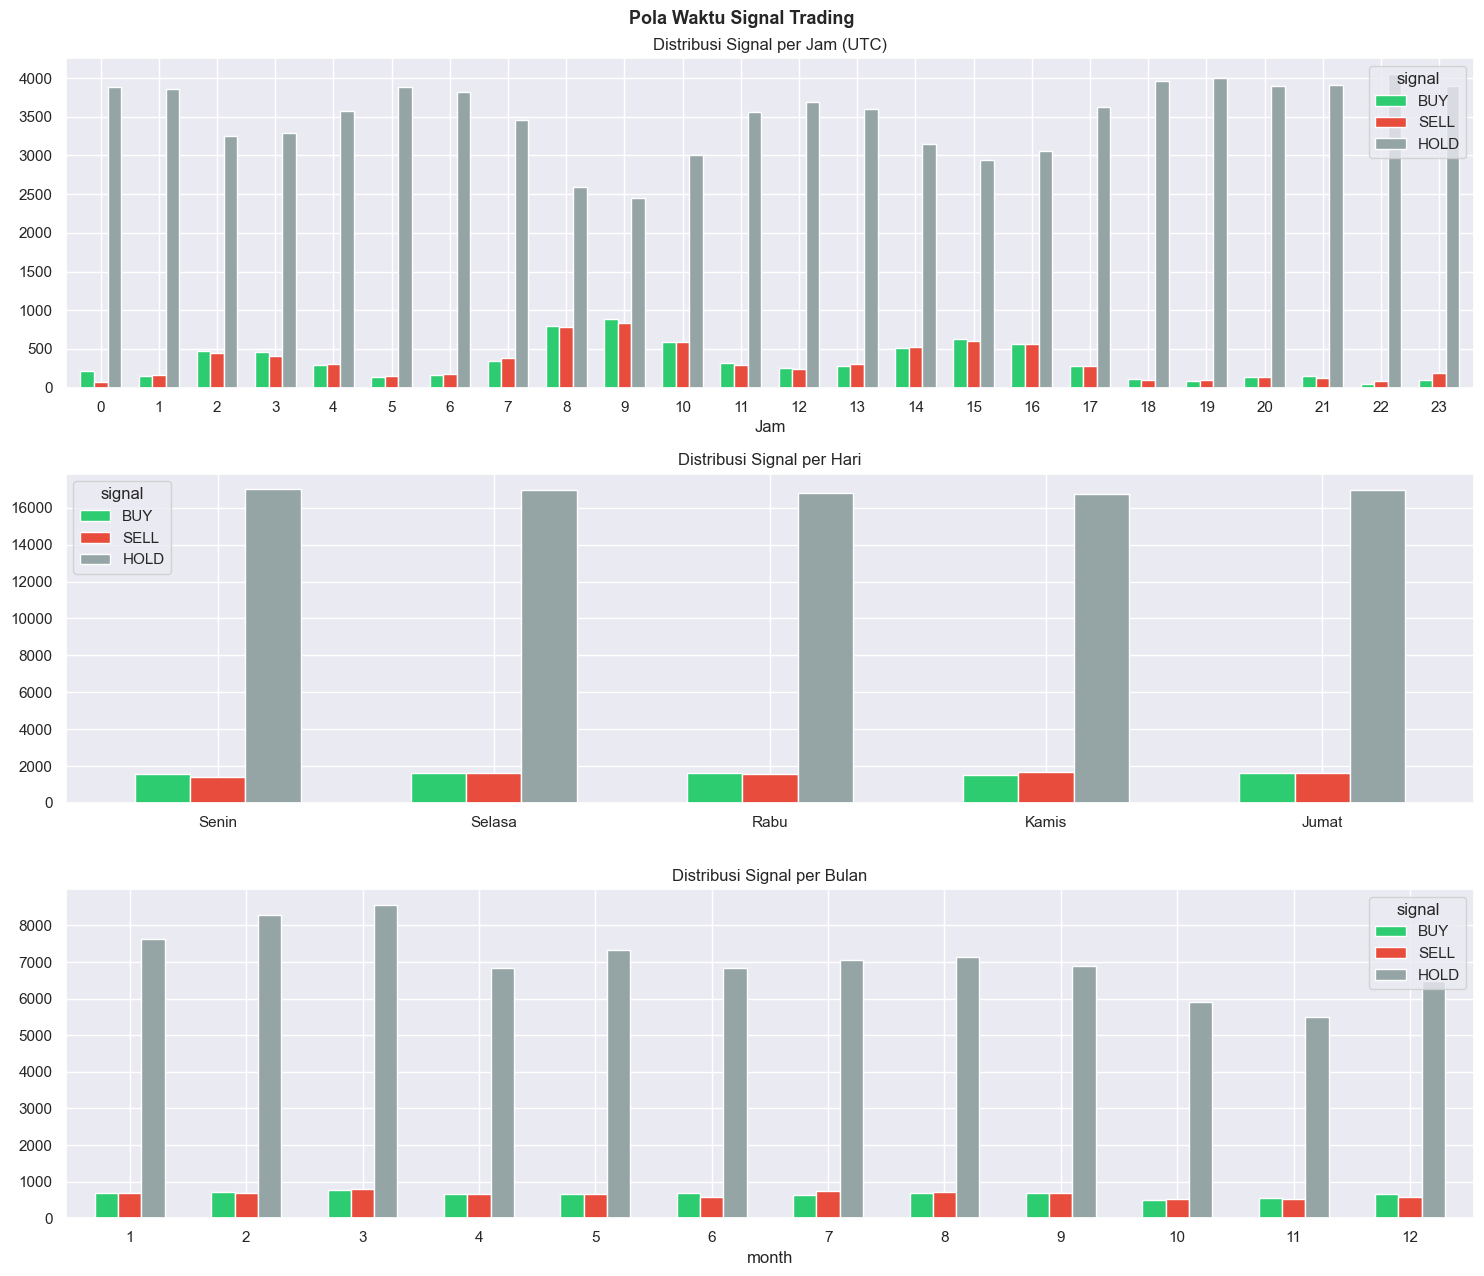

In [4]:
df['hour']       = df.index.hour
df['dayofweek']  = df.index.dayofweek   # 0=Senin, 4=Jumat
df['month']      = df.index.month
day_names = {0:'Senin', 1:'Selasa', 2:'Rabu', 3:'Kamis', 4:'Jumat'}

fig, axes = plt.subplots(3, 1, figsize=(15, 13))

# Per jam
hour_sig = df.groupby(['hour', 'signal']).size().unstack(fill_value=0)
hour_sig[['BUY','SELL','HOLD']].plot(kind='bar', ax=axes[0],
    color=['#2ecc71','#e74c3c','#95a5a6'], width=0.7, edgecolor='white')
axes[0].set_title('Distribusi Signal per Jam (UTC)')
axes[0].set_xlabel('Jam')
axes[0].tick_params(axis='x', rotation=0)

# Per hari
day_sig = df.groupby(['dayofweek', 'signal']).size().unstack(fill_value=0)
day_sig.index = [day_names.get(d, d) for d in day_sig.index]
day_sig[['BUY','SELL','HOLD']].plot(kind='bar', ax=axes[1],
    color=['#2ecc71','#e74c3c','#95a5a6'], width=0.6, edgecolor='white')
axes[1].set_title('Distribusi Signal per Hari')
axes[1].tick_params(axis='x', rotation=0)

# Per bulan
month_sig = df.groupby(['month', 'signal']).size().unstack(fill_value=0)
month_sig[['BUY','SELL','HOLD']].plot(kind='bar', ax=axes[2],
    color=['#2ecc71','#e74c3c','#95a5a6'], width=0.6, edgecolor='white')
axes[2].set_title('Distribusi Signal per Bulan')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Pola Waktu Signal Trading', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Validasi SL & TP — Apakah Wajar?

=== Statistik SL/TP (dalam pips) ===
        sl_pips   tp_pips        rr
count  15801.00  15801.00  15801.00
mean       6.74     13.47      2.00
std        3.57      7.14      0.02
min        1.30      2.50      1.92
25%        4.10      8.30      2.00
50%        6.00     11.90      2.00
75%        8.40     16.80      2.00
max       36.50     73.00      2.08


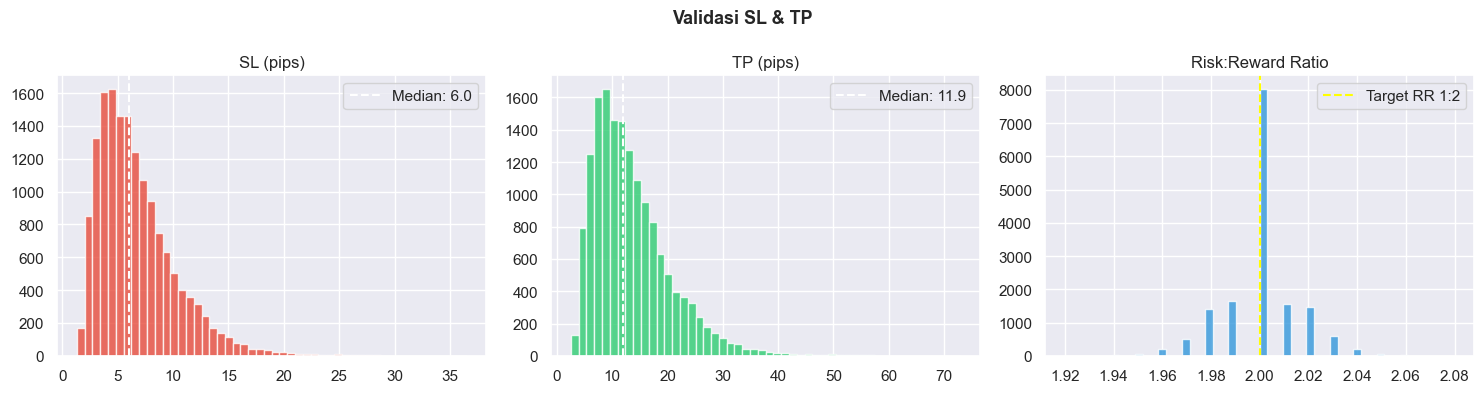


Median SL : 6.0 pips
Median TP : 11.9 pips
Median R:R : 1:2.00


In [5]:
df_trade = df[df['signal'].isin(['BUY','SELL'])].copy()

# Hitung jarak SL & TP dalam pips (1 pip EURUSD = 0.0001)
df_trade['sl_pips'] = ((df_trade['close'] - df_trade['sl']).abs() / 0.0001).round(1)
df_trade['tp_pips'] = ((df_trade['tp']    - df_trade['close']).abs() / 0.0001).round(1)
df_trade['rr']      = (df_trade['tp_pips'] / df_trade['sl_pips']).round(2)

print('=== Statistik SL/TP (dalam pips) ===')
print(df_trade[['sl_pips','tp_pips','rr']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_trade['sl_pips'], bins=50, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0].set_title('SL (pips)')
axes[0].axvline(df_trade['sl_pips'].median(), color='white', linestyle='--', label=f'Median: {df_trade["sl_pips"].median():.1f}')
axes[0].legend()

axes[1].hist(df_trade['tp_pips'], bins=50, color='#2ecc71', alpha=0.8, edgecolor='white')
axes[1].set_title('TP (pips)')
axes[1].axvline(df_trade['tp_pips'].median(), color='white', linestyle='--', label=f'Median: {df_trade["tp_pips"].median():.1f}')
axes[1].legend()

axes[2].hist(df_trade['rr'], bins=50, color='#3498db', alpha=0.8, edgecolor='white')
axes[2].set_title('Risk:Reward Ratio')
axes[2].axvline(2.0, color='yellow', linestyle='--', label='Target RR 1:2')
axes[2].legend()

plt.suptitle('Validasi SL & TP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nMedian SL : {df_trade["sl_pips"].median():.1f} pips')
print(f'Median TP : {df_trade["tp_pips"].median():.1f} pips')
print(f'Median R:R : 1:{df_trade["rr"].median():.2f}')

## 6. Korelasi Fitur dengan Signal

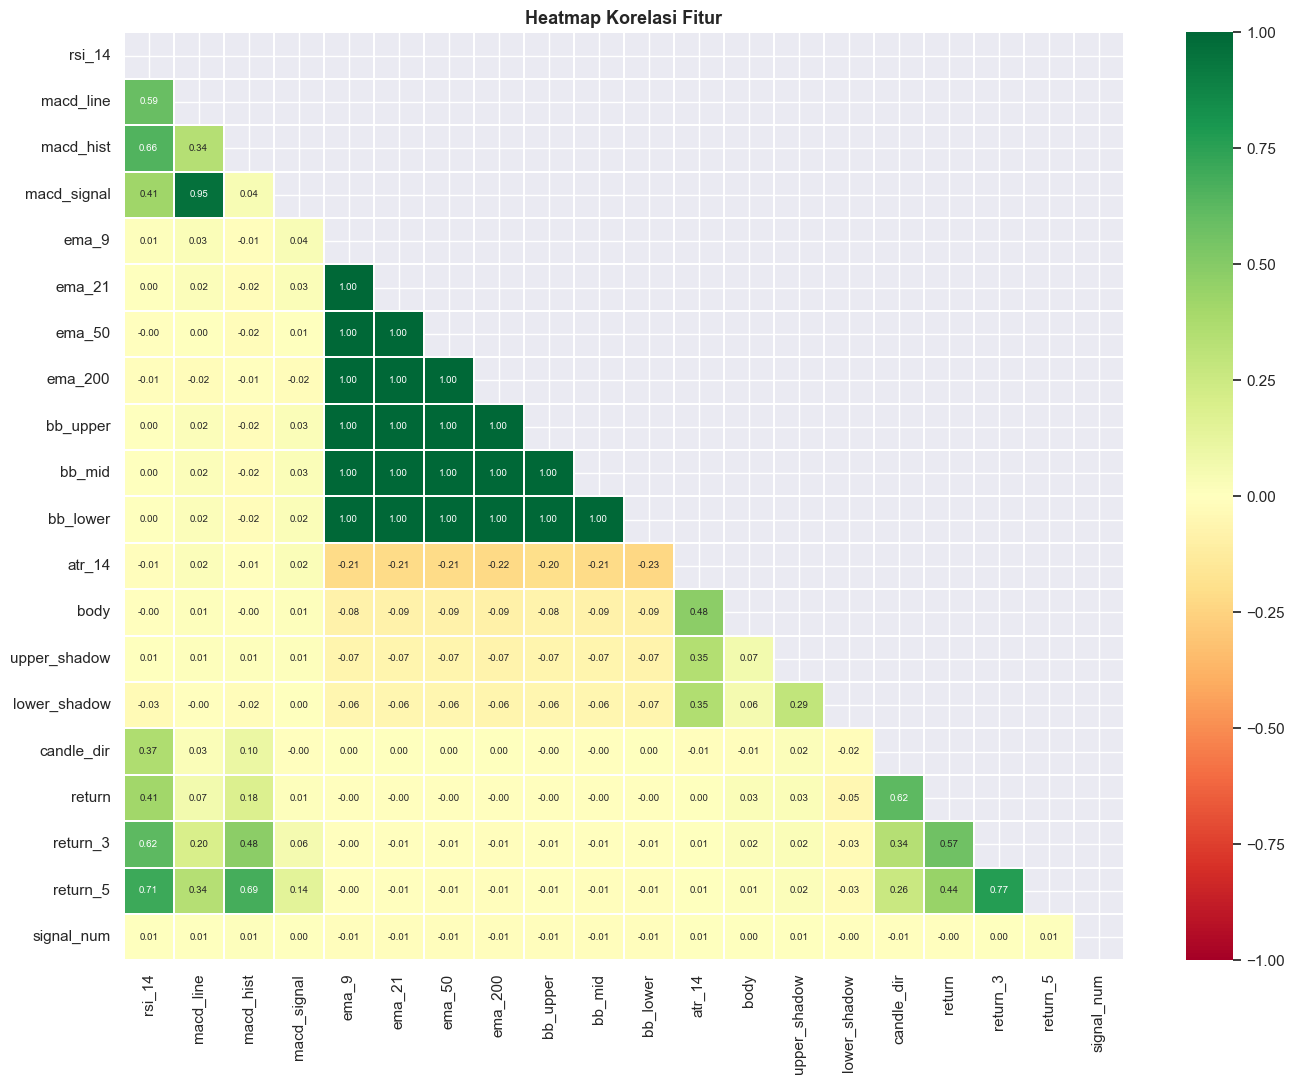


=== Top 10 Fitur Berkorelasi dengan Signal ===
  ema_200             : 0.0107
  bb_upper            : 0.0105
  ema_50              : 0.0105
  bb_mid              : 0.0105
  bb_lower            : 0.0105
  ema_21              : 0.0105
  ema_9               : 0.0104
  macd_hist           : 0.0100
  return_5            : 0.0080
  candle_dir          : 0.0066


In [6]:
# Encode signal ke angka untuk korelasi
signal_map = {'BUY': 1, 'HOLD': 0, 'SELL': -1}
df['signal_num'] = df['signal'].map(signal_map)

fitur_num = ['rsi_14', 'macd_line', 'macd_hist', 'macd_signal',
             'ema_9', 'ema_21', 'ema_50', 'ema_200',
             'bb_upper', 'bb_mid', 'bb_lower', 'atr_14',
             'body', 'upper_shadow', 'lower_shadow', 'candle_dir',
             'return', 'return_3', 'return_5', 'signal_num']

corr = df[fitur_num].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            annot_kws={'size': 7})
ax.set_title('Heatmap Korelasi Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top korelasi dengan signal
corr_signal = corr['signal_num'].drop('signal_num').abs().sort_values(ascending=False)
print('\n=== Top 10 Fitur Berkorelasi dengan Signal ===')
for feat, val in corr_signal.head(10).items():
    print(f'  {feat:20s}: {val:.4f}')

## 7. Kualitas Label — RSI & MACD saat BUY vs SELL

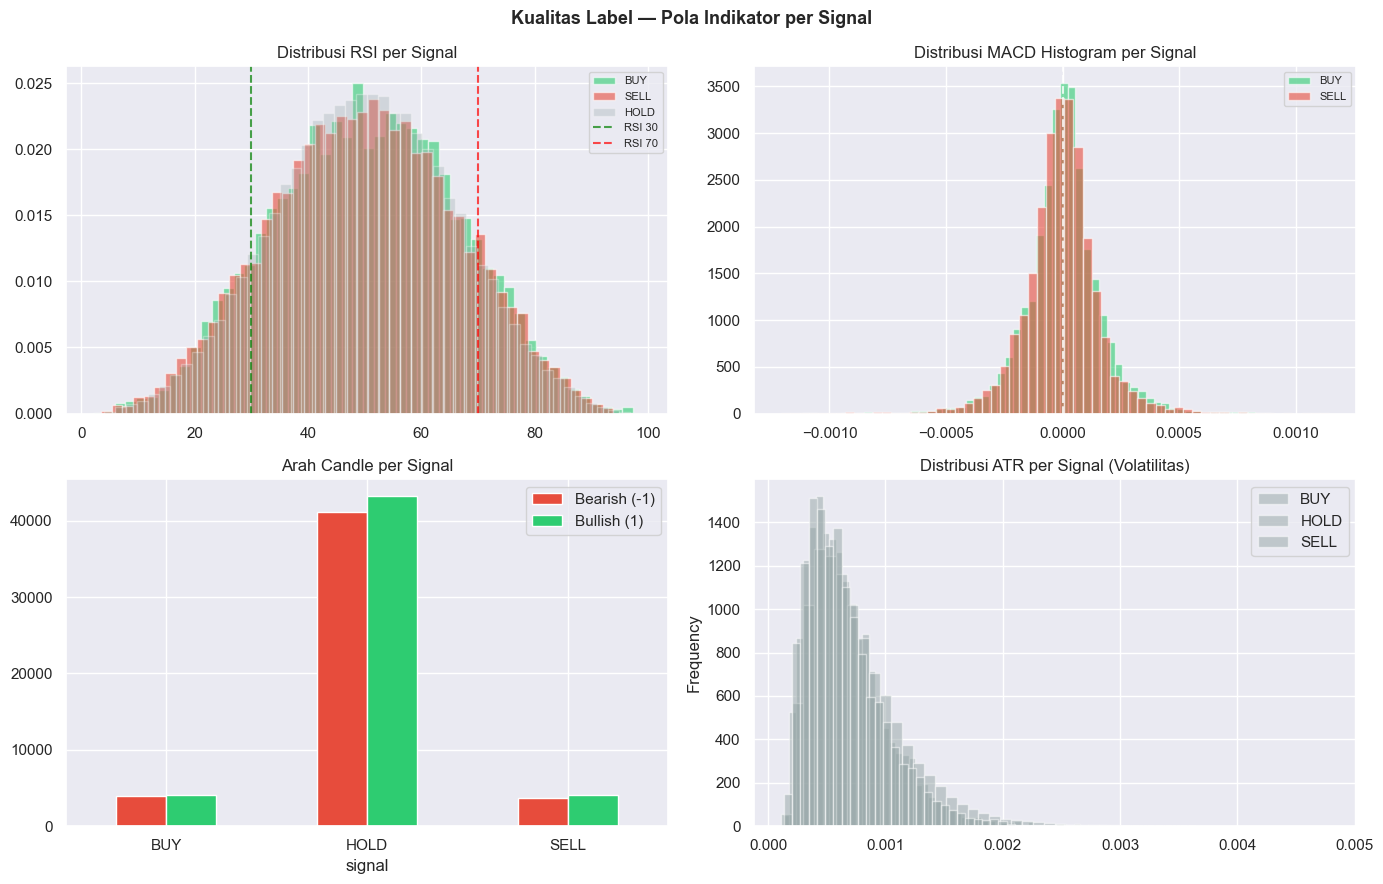

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

buy  = df[df['signal'] == 'BUY']
sell = df[df['signal'] == 'SELL']
hold = df[df['signal'] == 'HOLD']

# RSI distribution
axes[0,0].hist(buy['rsi_14'],  bins=50, alpha=0.6, color='#2ecc71', label='BUY',  density=True)
axes[0,0].hist(sell['rsi_14'], bins=50, alpha=0.6, color='#e74c3c', label='SELL', density=True)
axes[0,0].hist(hold['rsi_14'], bins=50, alpha=0.3, color='#95a5a6', label='HOLD', density=True)
axes[0,0].axvline(30, color='green', linestyle='--', alpha=0.7, label='RSI 30')
axes[0,0].axvline(70, color='red',   linestyle='--', alpha=0.7, label='RSI 70')
axes[0,0].set_title('Distribusi RSI per Signal')
axes[0,0].legend(fontsize=8)

# MACD histogram
axes[0,1].hist(buy['macd_hist'],  bins=60, alpha=0.6, color='#2ecc71', label='BUY',  density=True)
axes[0,1].hist(sell['macd_hist'], bins=60, alpha=0.6, color='#e74c3c', label='SELL', density=True)
axes[0,1].axvline(0, color='white', linestyle='--', alpha=0.8)
axes[0,1].set_title('Distribusi MACD Histogram per Signal')
axes[0,1].legend(fontsize=8)

# Candle direction
dir_counts = df.groupby(['signal', 'candle_dir']).size().unstack(fill_value=0)
dir_counts.columns = ['Bearish (-1)', 'Bullish (1)']
dir_counts.plot(kind='bar', ax=axes[1,0],
    color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1,0].set_title('Arah Candle per Signal')
axes[1,0].tick_params(axis='x', rotation=0)

# ATR per signal
df.groupby('signal')['atr_14'].plot(kind='hist', bins=50, alpha=0.5,
    ax=axes[1,1], legend=True, density=True,
    color=['#95a5a6','#2ecc71','#e74c3c'])
axes[1,1].set_title('Distribusi ATR per Signal (Volatilitas)')

plt.suptitle('Kualitas Label — Pola Indikator per Signal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Win Rate Label — Seberapa Bersih Labelnya?

In [8]:
# Cek konsistensi: saat BUY, apakah candle_dir memang bullish?
buy_bullish  = (buy['candle_dir'] == 1).mean() * 100
sell_bearish = (sell['candle_dir'] == -1).mean() * 100

print('=== Konsistensi Arah Candle ===')
print(f'  BUY  → candle bullish : {buy_bullish:.1f}%')
print(f'  SELL → candle bearish : {sell_bearish:.1f}%')

# RSI saat BUY (harapan: RSI tidak overbought)
buy_rsi_ok  = (buy['rsi_14'] < 70).mean() * 100
sell_rsi_ok = (sell['rsi_14'] > 30).mean() * 100

print(f'\n=== Konsistensi RSI ===')
print(f'  BUY  → RSI < 70 (tidak overbought): {buy_rsi_ok:.1f}%')
print(f'  SELL → RSI > 30 (tidak oversold)  : {sell_rsi_ok:.1f}%')

# MACD saat BUY (harapan: macd_hist positif)
buy_macd_ok  = (buy['macd_hist'] > 0).mean() * 100
sell_macd_ok = (sell['macd_hist'] < 0).mean() * 100

print(f'\n=== Konsistensi MACD ===')
print(f'  BUY  → MACD hist > 0: {buy_macd_ok:.1f}%')
print(f'  SELL → MACD hist < 0: {sell_macd_ok:.1f}%')

# Summary
avg_consistency = np.mean([buy_bullish, sell_bearish, buy_rsi_ok, sell_rsi_ok, buy_macd_ok, sell_macd_ok])
print(f'\nRata-rata konsistensi label: {avg_consistency:.1f}%')
if avg_consistency >= 60:
    print('✅ Label cukup bersih — pola terdeteksi dengan baik.')
else:
    print('⚠️  Label kurang konsisten — pertimbangkan ubah parameter labeling.')

=== Konsistensi Arah Candle ===
  BUY  → candle bullish : 50.6%
  SELL → candle bearish : 47.8%

=== Konsistensi RSI ===
  BUY  → RSI < 70 (tidak overbought): 87.6%
  SELL → RSI > 30 (tidak oversold)  : 88.2%

=== Konsistensi MACD ===
  BUY  → MACD hist > 0: 52.0%
  SELL → MACD hist < 0: 51.2%

Rata-rata konsistensi label: 62.9%
✅ Label cukup bersih — pola terdeteksi dengan baik.


## 9. Rangkuman EDA & Rekomendasi

In [9]:
print('=' * 55)
print('           RANGKUMAN EXPLORATORY DATA ANALYSIS')
print('=' * 55)

total = len(df)
n_buy  = counts.get('BUY', 0)
n_sell = counts.get('SELL', 0)
n_hold = counts.get('HOLD', 0)

print(f'\nDataset     : {total:,} candle M15 (Des 2021 - Mar 2026)')
print(f'Signal BUY  : {n_buy:,} ({n_buy/total*100:.1f}%)')
print(f'Signal SELL : {n_sell:,} ({n_sell/total*100:.1f}%)')
print(f'Signal HOLD : {n_hold:,} ({n_hold/total*100:.1f}%)')

print(f'\nMedian SL   : {df_trade["sl_pips"].median():.1f} pips')
print(f'Median TP   : {df_trade["tp_pips"].median():.1f} pips')
print(f'Median R:R  : 1:{df_trade["rr"].median():.2f}')

print('\n--- REKOMENDASI UNTUK TRAINING ---')
print('1. Handle imbalanced data:')
print('   → Gunakan class_weight="balanced" atau SMOTE')
print('   → Atau hapus sebagian HOLD (undersampling)')
print('2. Feature selection:')
print('   → Prioritaskan fitur dengan korelasi tinggi ke signal')
print('   → Hapus fitur yang highly correlated satu sama lain (multikolinearitas)')
print('3. Train/test split:')
print('   → Gunakan TimeSeriesSplit (bukan random split!)')
print('   → Contoh: 80% train (2021-2025), 20% test (2025-2026)')
print('4. Target:')
print('   → Opsi A: 3-class (BUY/SELL/HOLD)')
print('   → Opsi B: binary per arah (model BUY vs NOT, model SELL vs NOT)')
print('=' * 55)

           RANGKUMAN EXPLORATORY DATA ANALYSIS

Dataset     : 100,248 candle M15 (Des 2021 - Mar 2026)
Signal BUY  : 7,967 (7.9%)
Signal SELL : 7,834 (7.8%)
Signal HOLD : 84,447 (84.2%)

Median SL   : 6.0 pips
Median TP   : 11.9 pips
Median R:R  : 1:2.00

--- REKOMENDASI UNTUK TRAINING ---
1. Handle imbalanced data:
   → Gunakan class_weight="balanced" atau SMOTE
   → Atau hapus sebagian HOLD (undersampling)
2. Feature selection:
   → Prioritaskan fitur dengan korelasi tinggi ke signal
   → Hapus fitur yang highly correlated satu sama lain (multikolinearitas)
3. Train/test split:
   → Gunakan TimeSeriesSplit (bukan random split!)
   → Contoh: 80% train (2021-2025), 20% test (2025-2026)
4. Target:
   → Opsi A: 3-class (BUY/SELL/HOLD)
   → Opsi B: binary per arah (model BUY vs NOT, model SELL vs NOT)
